In [6]:
# Cell 0: synchronize the repository environment before running the workbench.
import subprocess
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Find the workspace root without confusing member pyproject files for it."""
    for candidate in (start, *start.parents):
        if (
            (candidate / "uv.lock").exists()
            and (candidate / "implementations").is_dir()
            and (candidate / "aieng-forecasting").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Could not find the agentic-forecasting repository root.")


SETUP_ROOT = find_repo_root(Path.cwd().resolve())
print("Running: uv sync --all-extras --dev --all-packages")
setup_result = subprocess.run(
    ["uv", "sync", "--all-extras", "--dev", "--all-packages"],
    cwd=SETUP_ROOT,
    check=False,
    text=True,
    capture_output=True,
)
print(setup_result.stdout)
if setup_result.returncode != 0:
    print(setup_result.stderr)
    raise RuntimeError("uv sync failed. Install uv or restart the notebook with the repository environment selected.")
print("Environment synchronized successfully.")
print("If packages changed, restart the notebook kernel before continuing.")

Running: uv sync --all-extras --dev --all-packages

Environment synchronized successfully.
If packages changed, restart the notebook kernel before continuing.


## Purpose and controls

The tuning stage compares historical frequency, six logistic regularization settings, and eight small XGBoost settings across three chronological folds within 2000-2017. The XGBoost candidates include shallower trees, slower learning rates, and a regularized depth-2 model. Each forecast is still fit using only data available at its own origin.

The selected fixed configuration for downstream workbenches is `logistic_c_0_001` for logistic regression and `xgb_50_depth2_lr0_03_minchild3_l2_5` for XGBoost. The hybrid numerical anchor uses the logistic candidate only; the full sweep remains available for reproducible model comparison.

The fixed 2018-2024 confirmation window was examined by an earlier run. Treat it as a historical diagnostic, not as an untouched holdout or a basis for claiming that the selected configuration beats the historical-frequency baseline. A clean next confirmation needs future or prospectively recorded outcomes.

In [7]:
# Main controls: change these values, then run the notebook from top to bottom.
STAGE = "tune"
CANDIDATE = None
BACKTEST_STRIDE = 3
REFRESH_INPUT_DATA = False
RUN_SWEEP = True
SHOW_ORIGIN_DETAILS = False

# For confirmation, use only a candidate that passes the tuning stability rule.
# Keep BACKTEST_STRIDE unchanged between stages.
print(
    {
        "stage": STAGE,
        "candidate": CANDIDATE,
        "backtest_stride": BACKTEST_STRIDE,
        "refresh_input_data": REFRESH_INPUT_DATA,
        "run_sweep": RUN_SWEEP,
        "show_origin_details": SHOW_ORIGIN_DETAILS,
    }
)

{'stage': 'tune', 'candidate': None, 'backtest_stride': 3, 'refresh_input_data': False, 'run_sweep': True, 'show_origin_details': False}


## Imports and active features

The notebook imports the candidate definitions and evaluation helpers from `run_parameter_smoke.py`; it does not duplicate the sweep logic. The active feature list is printed so changes in `features.py` are visible before the run starts.


In [8]:
from importlib import reload

import manufacturing_stress_forecasting.run_parameter_smoke as parameter_smoke
import yaml
from aieng.forecasting.evaluation import BacktestSpec
from dotenv import load_dotenv
from IPython.display import display as ipython_display
from manufacturing_stress_forecasting.data import build_manufacturing_stress_service
from manufacturing_stress_forecasting.features import FEATURE_SERIES_IDS


parameter_smoke = reload(parameter_smoke)
REPO_ROOT = SETUP_ROOT
load_dotenv(REPO_ROOT / ".env", override=False)
SPEC_PATH = (
    REPO_ROOT / "implementations" / "manufacturing_stress_forecasting" / "specs" / "manufacturing_stress_smoke.yaml"
)
print(f"Repository: {REPO_ROOT}")
print(f"Active statistical features ({len(FEATURE_SERIES_IDS)}):")
for feature_name in FEATURE_SERIES_IDS:
    print(f"  - {feature_name}")

Repository: C:\Users\Mina Attari\BMO-C2-agentic-forecasting
Active statistical features (15):
  - ipman_change_1m_pct
  - ipman_change_3m_pct
  - ipman_change_6m_pct
  - FEDFUNDS
  - YC_SPREAD
  - CPIAUCSL
  - CPI_YOY
  - UNRATE
  - ICSA
  - VIXCLS
  - CREDIT_SPREAD
  - SPY_RETURN_3M
  - SPY_RETURN_12M
  - XLI_RETURN_3M
  - XLI_RETURN_12M


## Create or refresh the data service

The default reads the existing local FRED and Yahoo Finance caches. Set `REFRESH_INPUT_DATA = True` only when you intentionally want to download fresh source data.


In [9]:
service = build_manufacturing_stress_service(
    cache_dir=REPO_ROOT / "data" / "fred",
    yahoo_cache_dir=REPO_ROOT / "data" / "yfinance",
    refresh=REFRESH_INPUT_DATA,
)
ipython_display(service.summary())

,series_id,description,source,units,frequency,n_obs,start,end
0,CPIAUCSL,Consumer Price Index for All Urban Consumers,FRED (CPIAUCSL),Index,MS,955,1947-01-01,2026-08-01
1,CPI_YOY,Consumer Price Index year-over-year change,Derived from FRED (CPIAUCSL),Percent,MS,943,1948-01-01,2026-08-01
2,CREDIT_SPREAD,Moody's Baa corporate bond yield minus 10-year...,FRED (BAA10Y),Percentage points,MS,489,1986-01-01,2026-09-01
3,FEDFUNDS,Effective federal funds rate,FRED (FEDFUNDS),Percent,MS,866,1954-07-01,2026-08-01
4,ICSA,Initial claims for unemployment insurance,FRED (ICSA),Number,MS,717,1967-01-01,2026-09-01
5,SPY_RETURN_12M,SPY trailing 12-month adjusted-close return,"Yahoo Finance (SPY), derived",Percent,MS,334,1999-01-01,2026-10-01
6,SPY_RETURN_3M,SPY trailing 3-month adjusted-close return,"Yahoo Finance (SPY), derived",Percent,MS,343,1998-04-01,2026-10-01
7,UNRATE,U.S. unemployment rate,FRED (UNRATE),Percent,MS,943,1948-01-01,2026-08-01
8,VIXCLS,CBOE volatility index,FRED (VIXCLS),Index,MS,441,1990-01-01,2026-09-01
9,XLI_RETURN_12M,XLI trailing 12-month adjusted-close return,"Yahoo Finance (XLI), derived",Percent,MS,323,1999-12-01,2026-10-01


## Build the tuning or confirmation experiment

The stage determines the date window and candidate set. Tuning runs the historical-frequency baseline plus every configured candidate. Confirmation runs the baseline plus exactly one selected candidate.


In [10]:
if STAGE not in {"tune", "confirm"}:
    raise ValueError("STAGE must be 'tune' or 'confirm'.")
if BACKTEST_STRIDE not in {1, 3}:
    raise ValueError("BACKTEST_STRIDE must be 1 or 3.")
if STAGE == "confirm" and CANDIDATE is None:
    raise ValueError("Set CANDIDATE to the tuning winner before confirmation.")
if STAGE == "tune" and CANDIDATE is not None:
    raise ValueError("Leave CANDIDATE as None during tuning.")

with SPEC_PATH.open() as file:
    base_spec = BacktestSpec.model_validate(yaml.safe_load(file))

spec = parameter_smoke.build_experiment_spec(base_spec, stage=STAGE, stride=BACKTEST_STRIDE)
named_predictors = parameter_smoke.predictors_for_stage(STAGE, CANDIDATE)

print(
    f"Stage={STAGE}; origins={spec.start.date()} to {spec.end.date()}; "
    f"stride={spec.stride}; horizon={spec.task.horizons[0]} month(s)"
)
print("Predictors:")
for predictor_name, _ in named_predictors:
    print(f"  - {predictor_name}")

if STAGE == "tune":
    print("Configured candidates:")
    for candidate in parameter_smoke.CANDIDATES:
        print(f"  - {candidate.name}")

Stage=tune; origins=2000-01-01 to 2017-12-01; stride=3; horizon=3 month(s)
Predictors:
  - historical_frequency
  - logistic_c_0_001
  - logistic_c_0_003
  - logistic_c_0_01
  - logistic_c_0_03
  - logistic_c_0_1
  - logistic_c_1_0
  - xgb_25_depth1_lr0_05
  - xgb_50_depth1_lr0_05
  - xgb_50_depth2_lr0_03
  - xgb_100_depth2_lr0_05
  - xgb_25_depth1_lr0_03
  - xgb_50_depth1_lr0_03
  - xgb_100_depth2_lr0_02
  - xgb_50_depth2_lr0_03_minchild3_l2_5
Configured candidates:
  - logistic_c_0_001
  - logistic_c_0_003
  - logistic_c_0_01
  - logistic_c_0_03
  - logistic_c_0_1
  - logistic_c_1_0
  - xgb_25_depth1_lr0_05
  - xgb_50_depth1_lr0_05
  - xgb_50_depth2_lr0_03
  - xgb_100_depth2_lr0_05
  - xgb_25_depth1_lr0_03
  - xgb_50_depth1_lr0_03
  - xgb_100_depth2_lr0_02
  - xgb_50_depth2_lr0_03_minchild3_l2_5


## Run the parameter sweep

Tuning runs 15 predictors across three folds, so it can take a while. Set `RUN_SWEEP = False` to inspect the setup without running models. Set `SHOW_ORIGIN_DETAILS = True` only when you need every forecast probability and resolved label.

In [11]:
results = None
fold_results = None
fold_table = None
pooled_table = None
origin_details = None
table = None
if RUN_SWEEP:
    if STAGE == "tune":
        fold_results = parameter_smoke.run_tuning_folds(
            base_spec=base_spec,
            stride=BACKTEST_STRIDE,
            service=service,
        )
        fold_table, pooled_table, origin_details = parameter_smoke.tuning_summary_tables(
            fold_results,
            service=service,
        )
    else:
        results = parameter_smoke.run_candidates(named_predictors, spec=spec, service=service)
        table = parameter_smoke.comparison_table(results)
else:
    print("Sweep skipped because RUN_SWEEP is False.")

Tuning fold 2000-2005...
Running historical_frequency...
Running logistic_c_0_001...
Running logistic_c_0_003...
Running logistic_c_0_01...
Running logistic_c_0_03...
Running logistic_c_0_1...
Running logistic_c_1_0...
Running xgb_25_depth1_lr0_05...
Running xgb_50_depth1_lr0_05...
Running xgb_50_depth2_lr0_03...
Running xgb_100_depth2_lr0_05...
Running xgb_25_depth1_lr0_03...
Running xgb_50_depth1_lr0_03...
Running xgb_100_depth2_lr0_02...
Running xgb_50_depth2_lr0_03_minchild3_l2_5...
Tuning fold 2006-2011...
Running historical_frequency...
Running logistic_c_0_001...
Running logistic_c_0_003...
Running logistic_c_0_01...
Running logistic_c_0_03...
Running logistic_c_0_1...
Running logistic_c_1_0...
Running xgb_25_depth1_lr0_05...
Running xgb_50_depth1_lr0_05...
Running xgb_50_depth2_lr0_03...
Running xgb_100_depth2_lr0_05...
Running xgb_25_depth1_lr0_03...
Running xgb_50_depth1_lr0_03...
Running xgb_100_depth2_lr0_02...
Running xgb_50_depth2_lr0_03_minchild3_l2_5...
Tuning fold 2012

## Compare Brier scores

The first table reports Brier score, skill against historical frequency, and stress-event counts by fold. The second pools the tuning folds and reports how many folds, including event-bearing folds, each candidate beats the baseline in. Lower Brier is better.

A candidate is suggested only when it improves pooled Brier, beats the baseline in at least two folds, and improves on an event-bearing fold. If stress events appear in fewer than two folds, treat any selected candidate as provisional. `SHOW_ORIGIN_DETAILS` reveals the forecast-level probabilities, labels, and Brier scores.

In [12]:
if STAGE == "tune" and fold_results is not None:
    fold_table, pooled_table, origin_details = parameter_smoke.tuning_summary_tables(fold_results, service=service)
    ipython_display(
        fold_table.style.format(
            {
                "mean_brier": "{:.4f}",
                "delta_vs_baseline": "{:+.4f}",
                "brier_skill": "{:+.1%}",
            }
        )
    )
    ipython_display(
        pooled_table.style.format(
            {
                "mean_brier": "{:.4f}",
                "delta_vs_baseline": "{:+.4f}",
                "brier_skill": "{:+.1%}",
            }
        )
    )

    selected_model = parameter_smoke.select_tuning_candidate(pooled_table)
    if selected_model is None:
        print(
            "No candidate beat historical frequency overall, in at least two folds, "
            "and in an event-bearing fold. Keep historical frequency."
        )
    else:
        selected_candidate = str(selected_model["candidate"])
        print(f"Tuning candidate passing the stability rule: {selected_candidate}")
        if int(selected_model["event_folds"]) < 2:
            print(
                "Caution: stress events appear in fewer than two folds; treat this candidate as provisional."
            )
        print("To reproduce the historical diagnostic, set:")
        print('STAGE = "confirm"')
        print(f'CANDIDATE = "{selected_candidate}"')
        print(f"BACKTEST_STRIDE = {BACKTEST_STRIDE}")
        print("The 2018Ã¢â‚¬â€œ2024 window has already been inspected and is not an untouched confirmation set.")

    if SHOW_ORIGIN_DETAILS:
        ipython_display(origin_details)
elif STAGE == "confirm" and table is not None:
    ipython_display(
        table.style.format(
            {
                "mean_brier": "{:.4f}",
                "delta_vs_baseline": "{:+.4f}",
                "brier_skill": "{:+.1%}",
            }
        )
    )
    print(f"Historical diagnostic completed for {CANDIDATE}; do not tune against this window.")

,candidate,fold,mean_brier,delta_vs_baseline,brier_skill,scored,skipped,stress_events
0,historical_frequency,2000-2005,0.0033,+0.0000,+0.0%,24,0,0
1,logistic_c_0_001,2000-2005,0.0008,-0.0025,+74.7%,24,0,0
2,logistic_c_0_003,2000-2005,0.0008,-0.0025,+74.7%,24,0,0
3,logistic_c_0_01,2000-2005,0.0008,-0.0025,+74.7%,24,0,0
4,logistic_c_0_03,2000-2005,0.0008,-0.0025,+74.7%,24,0,0
5,logistic_c_0_1,2000-2005,0.0008,-0.0025,+74.7%,24,0,0
6,logistic_c_1_0,2000-2005,0.0008,-0.0025,+74.7%,24,0,0
7,xgb_25_depth1_lr0_05,2000-2005,0.0008,-0.0025,+74.7%,24,0,0
8,xgb_50_depth1_lr0_05,2000-2005,0.0008,-0.0025,+74.7%,24,0,0
9,xgb_50_depth2_lr0_03,2000-2005,0.0008,-0.0025,+74.7%,24,0,0


,candidate,mean_brier,delta_vs_baseline,brier_skill,scored,skipped,stress_events,folds_beating_baseline,event_folds,event_folds_beating_baseline
0,logistic_c_1_0,0.0468,-0.0190,+28.8%,72,0,5,3,1,1
1,logistic_c_0_1,0.0523,-0.0135,+20.5%,72,0,5,3,1,1
2,logistic_c_0_03,0.0537,-0.0122,+18.5%,72,0,5,3,1,1
3,logistic_c_0_01,0.0607,-0.0051,+7.7%,72,0,5,3,1,1
4,historical_frequency,0.0658,+0.0000,+0.0%,72,0,5,0,1,0
5,logistic_c_0_003,0.0671,+0.0013,-1.9%,72,0,5,1,1,0
6,logistic_c_0_001,0.0691,+0.0032,-4.9%,72,0,5,1,1,0
7,xgb_25_depth1_lr0_03,0.0723,+0.0065,-9.8%,72,0,5,2,1,0
8,xgb_100_depth2_lr0_02,0.0728,+0.0070,-10.6%,72,0,5,2,1,0
9,xgb_50_depth2_lr0_03,0.0736,+0.0077,-11.7%,72,0,5,2,1,0


Tuning candidate passing the stability rule: logistic_c_1_0
Caution: stress events appear in fewer than two folds; treat this candidate as provisional.
To reproduce the historical diagnostic, set:
STAGE = "confirm"
CANDIDATE = "logistic_c_1_0"
BACKTEST_STRIDE = 3
The 2018Ã¢â‚¬â€œ2024 window has already been inspected and is not an untouched confirmation set.


Saved plot: C:\Users\Mina Attari\BMO-C2-agentic-forecasting\implementations\manufacturing_stress_forecasting\implementations\manufacturing_stress_forecasting\reports\parameter_sweep_results.png


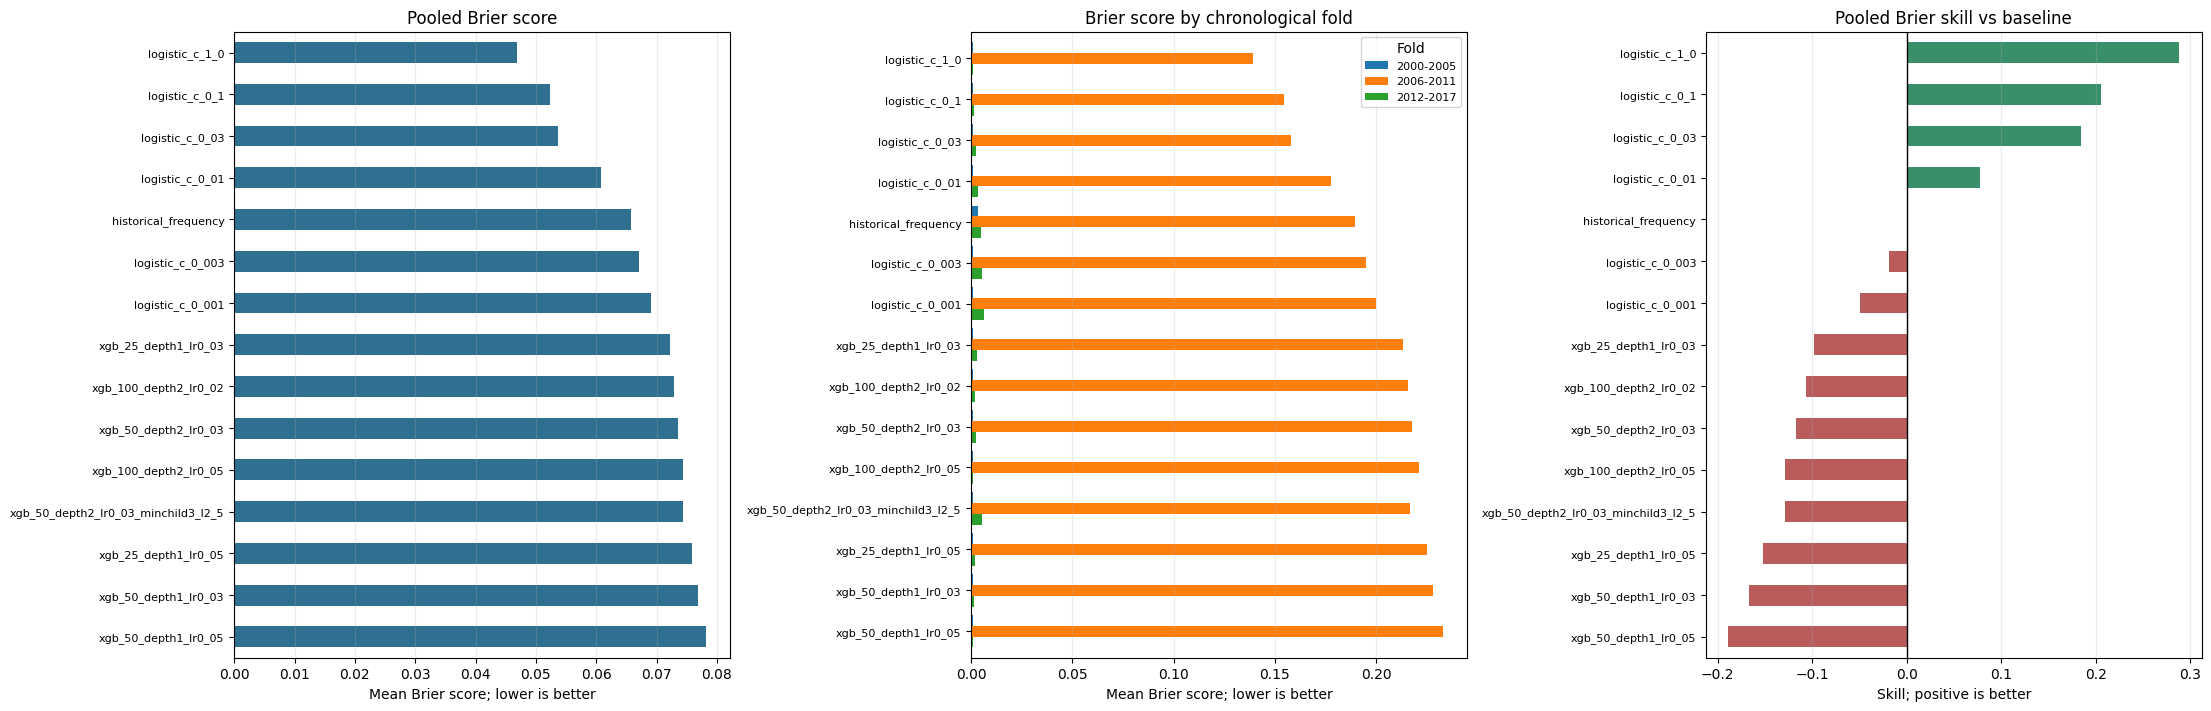

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

if pooled_table is None or fold_table is None:
    raise RuntimeError("Run the tuning sweep and comparison cell before creating plots.")

plot_pooled = pooled_table.sort_values("mean_brier", ascending=True).copy()
plot_folds = fold_table.copy()

fig, axes = plt.subplots(1, 3, figsize=(22, 7), constrained_layout=True)

plot_pooled.plot.barh(
    x="candidate",
    y="mean_brier",
    ax=axes[0],
    legend=False,
    color="#2f6f8f",
)
axes[0].invert_yaxis()
axes[0].set_title("Pooled Brier score")
axes[0].set_xlabel("Mean Brier score; lower is better")
axes[0].set_ylabel("")

fold_pivot = plot_folds.pivot(index="candidate", columns="fold", values="mean_brier")
fold_pivot = fold_pivot.reindex(plot_pooled["candidate"])
fold_pivot.plot.barh(ax=axes[1], width=0.8)
axes[1].invert_yaxis()
axes[1].set_title("Brier score by chronological fold")
axes[1].set_xlabel("Mean Brier score; lower is better")
axes[1].set_ylabel("")
axes[1].legend(title="Fold", fontsize=8)

plot_pooled.plot.barh(
    x="candidate",
    y="brier_skill",
    ax=axes[2],
    legend=False,
    color=plot_pooled["brier_skill"].ge(0).map({True: "#3a8f6b", False: "#b85c5c"}),
)
axes[2].axvline(0.0, color="black", linewidth=1)
axes[2].invert_yaxis()
axes[2].set_title("Pooled Brier skill vs baseline")
axes[2].set_xlabel("Skill; positive is better")
axes[2].set_ylabel("")

for axis in axes:
    axis.tick_params(axis="y", labelsize=8)
    axis.grid(axis="x", alpha=0.25)

report_dir = Path(REPO_ROOT) / "implementations" / "manufacturing_stress_forecasting" / "reports" / "param_sweep"
report_dir.mkdir(parents=True, exist_ok=True)
figure_path = report_dir / "parameter_sweep_results.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
print(f"Saved plot: {figure_path.resolve()}")
plt.show()

In [ ]:
from pathlib import Path

confirmation_spec = parameter_smoke.build_experiment_spec(
    base_spec,
    stage="confirm",
    stride=BACKTEST_STRIDE,
)
confirmation_predictors = parameter_smoke.predictors_for_stage("tune")
print(
    f"Evaluating {len(confirmation_predictors)} models on the historical confirmation window "
    f"{confirmation_spec.start.date()} to {confirmation_spec.end.date()}"
)
confirmation_results = parameter_smoke.run_candidates(
    confirmation_predictors,
    spec=confirmation_spec,
    service=service,
)
confirmation_table = parameter_smoke.comparison_table(confirmation_results)

report_dir = Path(REPO_ROOT) / "implementations" / "manufacturing_stress_forecasting" / "reports"
report_dir.mkdir(parents=True, exist_ok=True)
confirmation_table.to_csv(report_dir / "confirmation_2018_2024_results.csv", index=False)
confirmation_table.to_markdown(
    report_dir / "confirmation_2018_2024_results.md",
    index=False,
    floatfmt=".4f",
)
ipython_display(
    confirmation_table.style.format(
        {
            "mean_brier": "{:.4f}",
            "delta_vs_baseline": "{:+.4f}",
            "brier_skill": "{:+.1%}",
        }
    )
)
print(f"Saved confirmation table to {report_dir}")

Evaluating 15 models on the historical confirmation window 2018-01-01 to 2024-12-01
Running historical_frequency...
Running logistic_c_0_001...
Running logistic_c_0_003...
Running logistic_c_0_01...
Running logistic_c_0_03...
Running logistic_c_0_1...
Running logistic_c_1_0...
Running xgb_25_depth1_lr0_05...
Running xgb_50_depth1_lr0_05...
Running xgb_50_depth2_lr0_03...
Running xgb_100_depth2_lr0_05...
Running xgb_25_depth1_lr0_03...
Running xgb_50_depth1_lr0_03...
Running xgb_100_depth2_lr0_02...
Running xgb_50_depth2_lr0_03_minchild3_l2_5...


,candidate,mean_brier,delta_vs_baseline,brier_skill,scored,skipped
0,historical_frequency,0.0356,+0.0000,+0.0%,28,0
1,logistic_c_0_001,0.0380,+0.0024,-6.7%,28,0
2,xgb_50_depth2_lr0_03_minchild3_l2_5,0.0422,+0.0066,-18.4%,28,0
3,xgb_25_depth1_lr0_03,0.0426,+0.0070,-19.7%,28,0
4,xgb_25_depth1_lr0_05,0.0485,+0.0129,-36.2%,28,0
5,logistic_c_0_003,0.0516,+0.0160,-45.0%,28,0
6,xgb_50_depth1_lr0_03,0.0521,+0.0165,-46.3%,28,0
7,xgb_50_depth2_lr0_03,0.0643,+0.0287,-80.7%,28,0
8,xgb_50_depth1_lr0_05,0.0682,+0.0326,-91.5%,28,0
9,logistic_c_0_01,0.0716,+0.0360,-101.0%,28,0


Saved confirmation table to C:\Users\Mina Attari\BMO-C2-agentic-forecasting\reports


Saved confirmation plot: C:\Users\Mina Attari\BMO-C2-agentic-forecasting\implementations\manufacturing_stress_forecasting\reports\confirmation_2018_2024_results.png


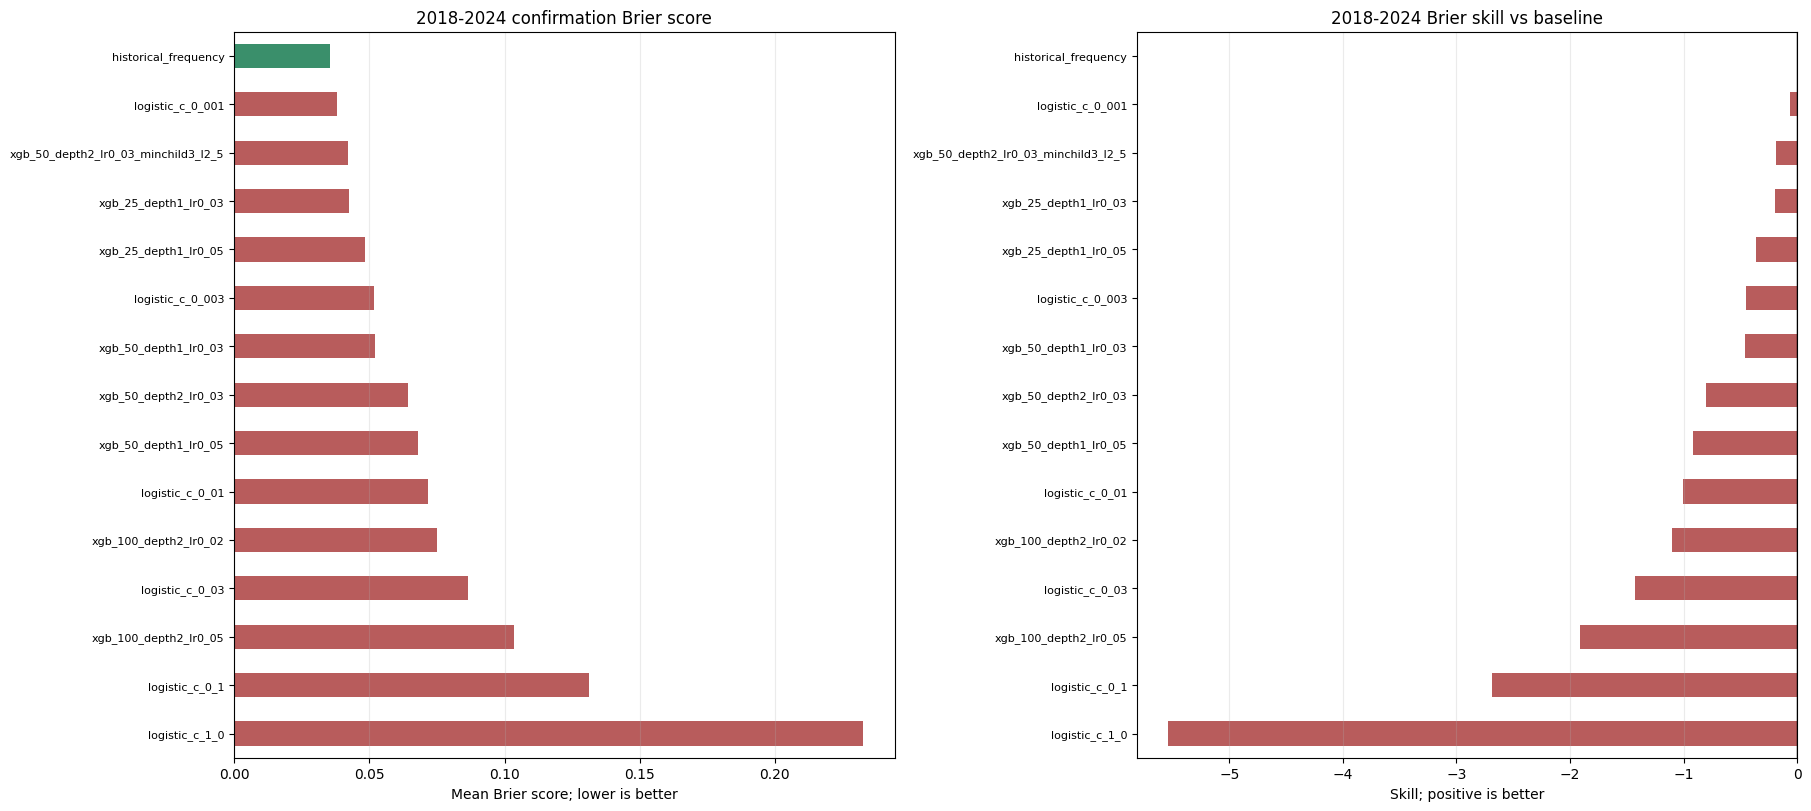

In [17]:
import matplotlib.pyplot as plt
from pathlib import Path

if "confirmation_table" not in globals() or confirmation_table is None:
    raise RuntimeError("Run the confirmation-results cell before creating confirmation plots.")

plot_confirmation = confirmation_table.sort_values("mean_brier", ascending=True).copy()
plot_confirmation["color"] = plot_confirmation["brier_skill"].ge(0).map(
    {True: "#3a8f6b", False: "#b85c5c"}
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

plot_confirmation.plot.barh(
    x="candidate",
    y="mean_brier",
    ax=axes[0],
    legend=False,
    color=plot_confirmation["color"],
)
axes[0].invert_yaxis()
axes[0].set_title("2018-2024 confirmation Brier score")
axes[0].set_xlabel("Mean Brier score; lower is better")
axes[0].set_ylabel("")

plot_confirmation.plot.barh(
    x="candidate",
    y="brier_skill",
    ax=axes[1],
    legend=False,
    color=plot_confirmation["color"],
)
axes[1].axvline(0.0, color="black", linewidth=1)
axes[1].invert_yaxis()
axes[1].set_title("2018-2024 Brier skill vs baseline")
axes[1].set_xlabel("Skill; positive is better")
axes[1].set_ylabel("")

for axis in axes:
    axis.tick_params(axis="y", labelsize=8)
    axis.grid(axis="x", alpha=0.25)

report_dir = Path(REPO_ROOT) / "implementations" / "manufacturing_stress_forecasting" / "reports"
report_dir.mkdir(parents=True, exist_ok=True)
figure_path = report_dir / "confirmation_2018_2024_results.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
print(f"Saved confirmation plot: {figure_path}")
plt.show()

## Confirmation discipline

The existing `confirm` stage evaluates one candidate on 2018Ã¢â‚¬â€œ2024, but that period has already been inspected. Use it only to reproduce or diagnose the historical result; do not choose parameters from it. For a fresh confirmation, freeze the candidate first and evaluate it only on future or prospectively recorded outcomes.